In [ ]:
from poincare import *
from symbolite import real
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from itertools import zip_longest

plt.style.use("seaborn-v0_8")

fontsize = 15
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)

class Duffing(System):
    t = Independent()
    x = initial(default=1)
    v = x.derive(initial=0)
    
    x_0 = assign(default=0)
    Dx = assign(default=(x-x_0))
    alpha = assign(default =1e-4/1.04) #Cte. elástica
    beta = assign(default = 0) # Termino cubico
    delta = assign(default=2.98e-03/1.04) # Amortiguamiento 

    eq = v.derive() << -alpha*Dx -beta *Dx**3 -delta*v 


In [125]:
np.rad2deg(0.05)

np.float64(2.8647889756541165)

Text(0.5, 0, 'Tiempo [s]')

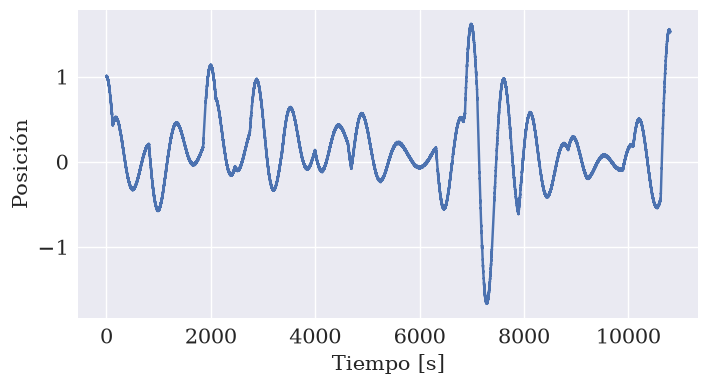

In [ ]:
# Patadas paramétricas (el equilibrio cambia azarosamente)
rng = np.random.default_rng(seed=42)
probabilidad_patada_eq = 1/(8*60) # 1/s
probabilidad_patada_v = 1/(8*60) # 1/s
std_patada_eq = 0.05
std_patada_v = 0.01
std_ruido = 0

sim = Simulator(Duffing)

# Dividir por tiempos
tiempos = np.linspace(0,180*60, int(5e4))
dt = tiempos[1]-tiempos[0]
limite_eq = probabilidad_patada_eq * dt
limite_v = probabilidad_patada_eq * dt
rand_eq = rng.random(len(tiempos))
rand_v = rng.random(len(tiempos))
mask_eq = rand_eq < limite_eq
mask_v = rand_v < limite_v
combined_mask = (mask_eq | mask_v)
combined_mask[0] = False 
split_indices = np.where(combined_mask)[0]
labels = []
for idx in split_indices:
    if mask_eq[idx]:
        labels.append("eq")
    else:
        labels.append("v")
subtiempos = np.split(tiempos, split_indices)

# Simular por partes
eq = {Duffing.x_0: 0}
utlimos_valores = {Duffing.x: 1, Duffing.v: 0}
vals = utlimos_valores | eq
resultados = []
equilibrios = []
for tiempo, tipo in zip_longest(subtiempos, labels):
    resultado = sim.solve(save_at=(tiempo), values = vals)
    resultados.append(resultado)
    patada_eq = rng.normal(0, std_patada_eq) if tipo == "eq" else 0
    patada_v = rng.normal(0, std_patada_v) if tipo == "v" else 0
    eq = {Duffing.x_0: eq[Duffing.x_0] + patada_eq} 
    equilibrios.append[eq[Duffing.x_0] + patada_eq]
    utlimos_valores = {Duffing.x: resultado["x"].values[-1], Duffing.v: resultado["v"].values[-1]+patada_v}
    vals = utlimos_valores | eq
resultado_final = xr.concat(resultados, dim = "time")

# Agregar ruido
resultado_final["x"] 

# Plots

resultado_final.to_dataframe()["x"].plot(figsize=(8,4))
plt.ylabel("Posición")
plt.xlabel("Tiempo [s]")